# Module 3C — Brake-Condition Classification (Local Training)

Option A redefines 3C around the logistics fleet dataset because EVIoT `Brake_Pad_Wear` was statistically disconnected from its predictors.

Train an XGBoost classifier to predict:

- `0`: Good → normal
- `1`: Fair → warning
- `2`: Poor → critical

Inputs are leakage-safe telemetry and usage fields. Maintenance type, maintenance severity, costs, derived health indexes, and predictive scores are deliberately excluded.

Artifact: `ml/models/brake_condition_xgb.joblib`.

In [ ]:
# Run once if dependencies are missing:
# %pip install -r ../apps/backend/requirements-phase3.txt

from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repository:", REPO_ROOT)
print("Python:", sys.version)

Repository: F:\BMW
Python: 3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from ml.predictive_maintenance.config import (
    BRAKE_CONDITION_MODEL_PATH,
    LOGISTICS_BRAKE_CLASS_NAMES,
    LOGISTICS_BRAKE_FEATURES,
    LOGISTICS_BRAKE_TARGET,
    LOGISTICS_TIRE_PATH,
)
from ml.predictive_maintenance.datasets import prepare_brake_frame

RANDOM_STATE = 42

print("Dataset:", LOGISTICS_TIRE_PATH)
print("Artifact:", BRAKE_CONDITION_MODEL_PATH)
print("xgboost:", xgboost.__version__, "sklearn:", sklearn.__version__)

Dataset: F:\BMW\data\predictive_maintenance\logistics_predictive_maintenanceV2.csv
Artifact: F:\BMW\ml\models\brake_condition_xgb.joblib
xgboost: 3.3.0 sklearn: 1.9.0


Rows: 250,000
Features: ['Usage_Hours', 'Actual_Load', 'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality', 'Failure_History', 'Anomalies_Detected', 'Diagnostic_Trouble_Code_Count', 'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', 'Days_Since_Last_Maintenance']
Target distribution:


Brake_Condition
Good    143688
Fair     75123
Poor     31189
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
Usage_Hours,250000.0,11599.769531,6295.169434,300.000000,6164.741943,11610.537109,17042.004883,24350.832031
Actual_Load,250000.0,6346.030273,5048.893555,525.028381,2039.542633,5077.010498,9456.292969,27496.171875
Engine_Temperature,250000.0,93.202065,10.446833,61.206402,85.787598,91.135647,98.968126,130.000000
Tire_Pressure,250000.0,33.397202,3.523209,16.875200,31.513901,33.962101,35.841499,44.282600
Fuel_Consumption,250000.0,9.596477,3.043484,4.000000,7.511100,8.696300,10.974000,23.820200
Battery_Status,250000.0,76.481667,14.056946,20.095501,68.343622,80.162201,86.584322,100.000000
Vibration_Levels,250000.0,2.042092,1.651715,0.000000,1.011000,1.464600,2.451900,10.704300
Oil_Quality,250000.0,78.969757,13.213932,20.000000,72.457422,82.728100,88.199526,100.000000
Failure_History,250000.0,0.607068,1.133718,0.000000,0.000000,0.000000,1.000000,10.000000
Anomalies_Detected,250000.0,0.750020,1.478135,0.000000,0.000000,0.000000,1.000000,13.000000


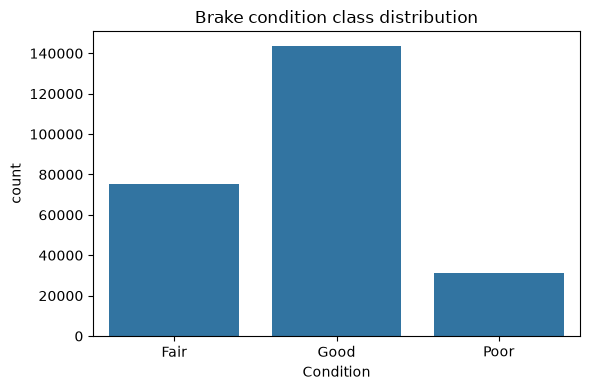

In [ ]:
data = prepare_brake_frame()
X = data.X.astype(np.float32)
y = data.y.astype(np.int64)

print(f"Rows: {len(X):,}")
print("Features:", list(X.columns))
print("Target distribution:")
display(y.value_counts().sort_index().rename(index=dict(enumerate(LOGISTICS_BRAKE_CLASS_NAMES))))
display(X.describe().T)

plt.figure(figsize=(6, 4))
sns.countplot(x=y.map(dict(enumerate(LOGISTICS_BRAKE_CLASS_NAMES))))
plt.title("Brake condition class distribution")
plt.xlabel("Condition")
plt.tight_layout()
plt.show()

## Leakage-safe stratified split

Reserve 20% as the final untouched test set. Split the remaining data into train and validation sets while preserving the Good/Fair/Poor class ratios.

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

print("train:", X_train.shape, "validation:", X_val.shape, "test:", X_test.shape)
for name, labels in (("train", y_train), ("validation", y_val), ("test", y_test)):
    print(name, labels.value_counts(normalize=True).sort_index().round(3).to_dict())

train: (160000, 14) validation: (40000, 14) test: (50000, 14)
train {0: 0.575, 1: 0.3, 2: 0.125}
validation {0: 0.575, 1: 0.3, 2: 0.125}
test {0: 0.575, 1: 0.3, 2: 0.125}


## Establish the majority-class baseline

The baseline always predicts `Good`, the most frequent training class. Macro F1 is the primary metric because `Poor` is less frequent and safety-relevant.

In [ ]:
majority_class = int(y_train.mode().iloc[0])
baseline_predictions = np.full(len(y_val), majority_class)
baseline_metrics = {
    "accuracy": float(accuracy_score(y_val, baseline_predictions)),
    "macro_f1": float(f1_score(y_val, baseline_predictions, average="macro")),
}
print("Majority class:", LOGISTICS_BRAKE_CLASS_NAMES[majority_class])
print("Validation baseline:", baseline_metrics)

Majority class: Good
Validation baseline: {'accuracy': 0.57475, 'macro_f1': 0.24331904535111393}


In [ ]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(LOGISTICS_BRAKE_CLASS_NAMES),
    n_estimators=700,
    max_depth=7,
    learning_rate=0.045,
    subsample=0.85,
    colsample_bytree=0.90,
    min_child_weight=3,
    reg_alpha=0.05,
    reg_lambda=1.25,
    eval_metric="mlogloss",
    early_stopping_rounds=40,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
print("Best iteration:", model.best_iteration)
print("Best validation mlogloss:", model.best_score)

Best iteration: 242
Best validation mlogloss: 0.6617968309344724


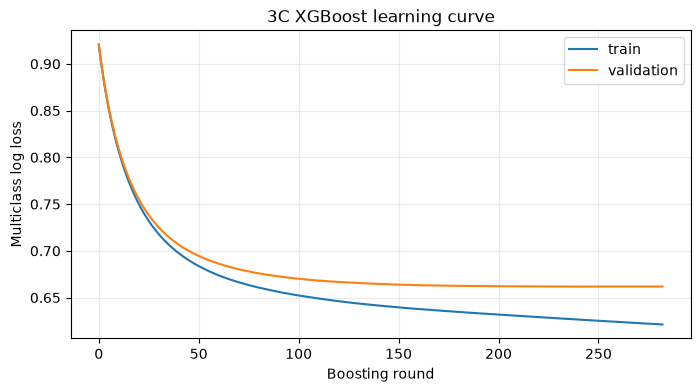

In [ ]:
history = model.evals_result()
plt.figure(figsize=(8, 4))
plt.plot(history["validation_0"]["mlogloss"], label="train")
plt.plot(history["validation_1"]["mlogloss"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("Multiclass log loss")
plt.title("3C XGBoost learning curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Final test evaluation

Evaluate the untouched test split. Inspect per-class recall and the normalized confusion matrix, especially the safety-critical `Poor` class.

In [ ]:
test_probabilities = model.predict_proba(X_test)
test_predictions = np.argmax(test_probabilities, axis=1)
test_metrics = {
    "accuracy": float(accuracy_score(y_test, test_predictions)),
    "macro_f1": float(f1_score(y_test, test_predictions, average="macro")),
    "weighted_f1": float(f1_score(y_test, test_predictions, average="weighted")),
    "log_loss": float(log_loss(y_test, test_probabilities, labels=range(len(LOGISTICS_BRAKE_CLASS_NAMES)))),
}
print("Baseline validation:", baseline_metrics)
print("XGBoost test:", test_metrics)
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=LOGISTICS_BRAKE_CLASS_NAMES,
        digits=4,
    )
)

Baseline validation: {'accuracy': 0.57475, 'macro_f1': 0.24331904535111393}
XGBoost test: {'accuracy': 0.70114, 'macro_f1': 0.6333927235485121, 'weighted_f1': 0.6783451443293832, 'log_loss': 0.6594551801681519}
              precision    recall  f1-score   support

        Good     0.7497    0.9121    0.8230     28737
        Fair     0.5046    0.3366    0.4038     15025
        Poor     0.7553    0.6076    0.6734      6238

    accuracy                         0.7011     50000
   macro avg     0.6699    0.6187    0.6334     50000
weighted avg     0.6767    0.7011    0.6783     50000



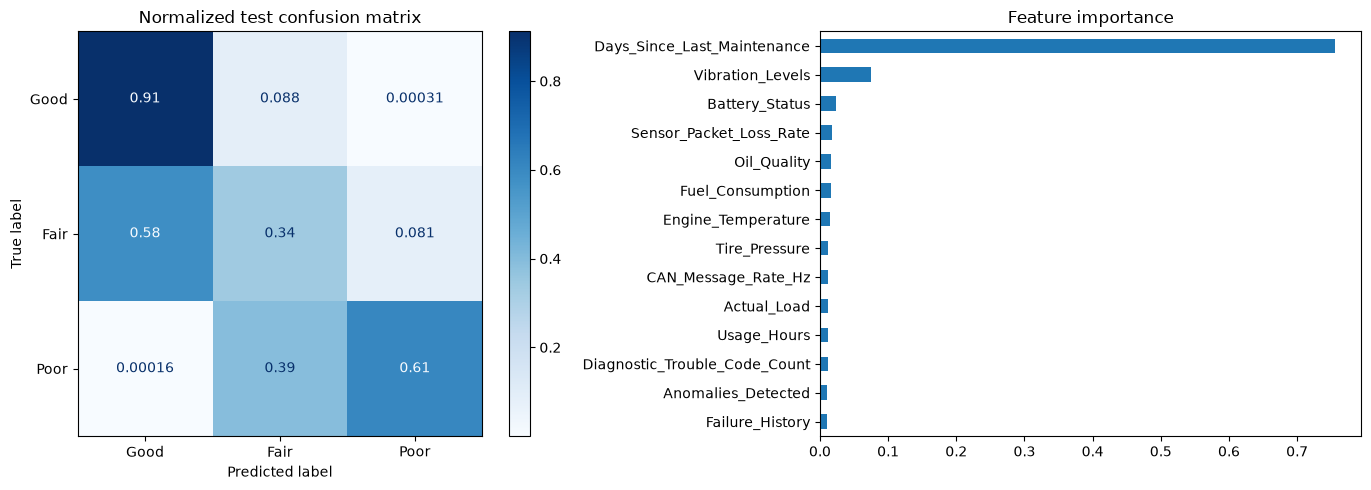

,importance
Days_Since_Last_Maintenance,0.756169
Vibration_Levels,0.075425
Battery_Status,0.023087
Sensor_Packet_Loss_Rate,0.017543
Oil_Quality,0.016155
Fuel_Consumption,0.016052
Engine_Temperature,0.014380
Tire_Pressure,0.012030
CAN_Message_Rate_Hz,0.011946
Actual_Load,0.011911


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=LOGISTICS_BRAKE_CLASS_NAMES,
    normalize="true",
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Normalized test confusion matrix")

importance = pd.Series(model.feature_importances_, index=LOGISTICS_BRAKE_FEATURES).sort_values()
importance.plot.barh(ax=axes[1])
axes[1].set_title("Feature importance")
plt.tight_layout()
plt.show()
display(importance.sort_values(ascending=False).to_frame("importance"))

## Save the inference bundle

The bundle stores the model, exact feature and class contracts, metrics, dataset provenance, and dependency versions for `BrakeConditionClassifier`.

In [ ]:
from datetime import datetime, timezone

BRAKE_CONDITION_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
bundle = {
    "schema_version": 1,
    "module": "3C",
    "task": "logistics_brake_condition_classification",
    "model": model,
    "features": list(LOGISTICS_BRAKE_FEATURES),
    "class_names": list(LOGISTICS_BRAKE_CLASS_NAMES),
    "target": LOGISTICS_BRAKE_TARGET,
    "metrics": test_metrics,
    "baseline_metrics": baseline_metrics,
    "dataset": str(LOGISTICS_TIRE_PATH),
    "rows": int(len(X)),
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "versions": {
        "xgboost": xgboost.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
}
joblib.dump(bundle, BRAKE_CONDITION_MODEL_PATH)
print(f"Saved {BRAKE_CONDITION_MODEL_PATH} ({BRAKE_CONDITION_MODEL_PATH.stat().st_size / 1024:.1f} KiB)")

Saved F:\BMW\ml\models\brake_condition_xgb.joblib (4133.2 KiB)


In [ ]:
from ml.predictive_maintenance.brake_model import BrakeConditionClassifier

runtime = BrakeConditionClassifier(model_path=BRAKE_CONDITION_MODEL_PATH)
result = runtime.predict(X_test.iloc[0].to_dict())
print("Actual:", LOGISTICS_BRAKE_CLASS_NAMES[int(y_test.iloc[0])])
print("Predicted:", result)
assert abs(sum(result.probabilities.values()) - 1.0) < 1e-5
print("3C artifact reload check passed.")

Actual: Good
Predicted: BrakeConditionResult(class_id=0, condition='Good', confidence=0.7667700052261353, probabilities={'Good': 0.7667700052261353, 'Fair': 0.23282910883426666, 'Poor': 0.0004008504911325872}, severity='normal', maintenance_required=False)
3C artifact reload check passed.
